# Imports

In [58]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from nltk.stem import WordNetLemmatizer
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Allan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Allan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# Load Data

In [93]:
df = pd.read_csv("../data.csv")
df.head()

,doc_id,text,category_1,category_2,sentiment
0,1,Trump's presidency has been tattered with scan...,1,none,Negative
1,2,My machine learning course has been really enj...,2,none,Positive
2,3,The plot of the final season of The Boys has b...,3,none,Negative
3,4,I enjoy getting learning about strength traini...,4,none,Positive
4,5,It's concerning our government is partnering w...,1,2,Negative


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   doc_id      650 non-null    int64
 1   text        650 non-null    str  
 2   category_1  650 non-null    int64
 3   category_2  553 non-null    str  
 4   sentiment   639 non-null    str  
dtypes: int64(2), str(3)
memory usage: 25.5 KB


In [5]:
df[df["category_2"].isnull()]

,doc_id,text,category_1,category_2,sentiment
50,51,Her background in classical singing contrasts ...,3,NaN,Positive
51,52,The rhythm and instrumentation are so bad that...,3,NaN,Negative
52,53,"The novel is told through fragments, with each...",3,NaN,Neutral
53,54,The most satisfying dessert you could ever hop...,5,NaN,Positive
54,55,The poem has lines so long that each stanza be...,3,NaN,Negative
...,...,...,...,...,...
590,591,Our software patch resolved the persistent bug...,2,NaN,Positive
591,592,My terrible sleep habits impact my physical en...,4,NaN,Negative
592,593,My favorite artist just released a new album. ...,3,NaN,Neutral
593,594,Many citizens voted in the yearly election. Th...,1,NaN,Positive


In [6]:
df.fillna({"category_2": "none"}, inplace=True)

,doc_id,text,category_1,category_2,sentiment
0,1,Trump's presidency has been tattered with scan...,1,none,Negative
1,2,My machine learning course has been really enj...,2,none,Positive
2,3,The plot of the final season of The Boys has b...,3,none,Negative
3,4,I enjoy getting learning about strength traini...,4,none,Positive
4,5,It's concerning our government is partnering w...,1,2,Negative
...,...,...,...,...,...
645,646,Cooking show made the recipe look easy and the...,3,5,Positive
646,647,Food critic's review was poor and the restaura...,3,5,Negative
647,648,"Home series covers cleaning routines, pet care...",3,5,Neutral
648,649,Gardening became a daily habit. The physical a...,4,5,Positive


In [7]:
df[df["sentiment"].isnull()]

,doc_id,text,category_1,category_2,sentiment
100,101,A successful recipe book includes the ingredie...,-1,none,NaN
101,102,Those in the United States government had a di...,-1,none,NaN
102,103,Poor sleep will negate all exercise completed ...,-1,none,NaN
103,104,The computer science student created an excell...,-1,none,NaN
104,105,The main actor and actress from the disappoint...,-1,none,NaN
105,106,A popular news article claims that a positive ...,-1,none,NaN
106,107,The intern at the local pilates studio made an...,-1,none,NaN
107,108,The mayor gave a strong speech protesting the ...,-1,none,NaN
108,109,The most popular headline from today says that...,-1,none,NaN
109,110,An author turned data scientist coded a very w...,-1,none,NaN


In [8]:
df = df[~df["sentiment"].isnull()]

In [9]:
df["category_1"].value_counts(normalize=True, dropna=False)

category_1
1    0.262911
2    0.219092
3    0.201878
4    0.183099
5    0.133020
Name: proportion, dtype: float64

In [10]:
df["category_2"].value_counts(normalize=True, dropna=False)

category_2
none     0.497653
5        0.176839
4        0.111111
3        0.097027
2        0.089202
1        0.025039
none     0.003130
Name: proportion, dtype: float64

In [11]:
df["category_2"] = df["category_2"].str.strip()

In [12]:
df["category_2"].value_counts(normalize=True, dropna=False)

category_2
none    0.500782
5       0.176839
4       0.111111
3       0.097027
2       0.089202
1       0.025039
Name: proportion, dtype: float64

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 639 entries, 0 to 649
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   doc_id      639 non-null    int64
 1   text        639 non-null    str  
 2   category_1  639 non-null    int64
 3   category_2  639 non-null    str  
 4   sentiment   639 non-null    str  
dtypes: int64(2), str(3)
memory usage: 30.0 KB


# Tasks
- Predict sentiment
- Predict Category 1
- Predict number of categories present
- Predict Categories Present

## Instructions
For your task

1. Find a baseline (predicting mode class)
2. Try different combinations of vectorizers, preprocessing, and models
   - probably make 3 lists of preprocesses, vectorizers, and models and run a grid search recording results using classification report and confusion matrix
3. Make a visual with the results, write your finding, and interpret

# Predict Categories Present

## Preprocessing

In [14]:
for label in df["category_1"].unique():
    col = f"{label}_present"
    df[col] = (df["category_1"] == label) + (df["category_2"] == label)
    df[col] = df[col].astype(bool)

In [15]:
df.head()

,doc_id,text,category_1,category_2,sentiment,1_present,2_present,3_present,4_present,5_present
0,1,Trump's presidency has been tattered with scan...,1,none,Negative,True,False,False,False,False
1,2,My machine learning course has been really enj...,2,none,Positive,False,True,False,False,False
2,3,The plot of the final season of The Boys has b...,3,none,Negative,False,False,True,False,False
3,4,I enjoy getting learning about strength traini...,4,none,Positive,False,False,False,True,False
4,5,It's concerning our government is partnering w...,1,2,Negative,True,False,False,False,False


In [63]:
pipes = {}
vecs = {"bow": CountVectorizer, "tfidf": TfidfVectorizer}
models = {"log_reg": LogisticRegression, "mnb": MultinomialNB, "svc": SVC}
stops = {"no": None, "yes": "english"}
ngrams = [i for i in range(1, 5)]

for model in models:
    for vec in vecs:
        for stop in stops:
            for end_gram in ngrams:
                key = f"{model}_{vec}_{stop}_{end_gram}"
                pipes[key] = {"models": {}}
                accs = []
                for label in df["category_1"].unique():
                    target = f"{label}_present"
                    X_train, X_test, y_train, y_test = train_test_split(df["text"], df[target], random_state=42, stratify=df[target])
                    if model == "mnb":
                        pipe = Pipeline([
                            ("vec", vecs[vec](stop_words=stops[stop], ngram_range=(1, end_gram))),
                            ("model", models[model]())
                        ])
                    else:
                        pipe = Pipeline([
                            ("vec", vecs[vec](stop_words=stops[stop], ngram_range=(1, end_gram))),
                            ("model", models[model](random_state=42))
                        ])
                    pipe.fit(X_train, y_train)
                    preds = pipe.predict(X_test)
                    accs.append(accuracy_score(y_test, preds))
                    pipes[key]["models"][label] = pipe
                pipes[key]["accuracy"] = np.mean(accs)

In [89]:
# print(pipes['log_reg_bow_no_1'])
# print(len(pipes))

In [91]:
# print(sorted([(key, pipes[key]["accuracy"]) for key in pipes], key=lambda x: x[-1], reverse=True))

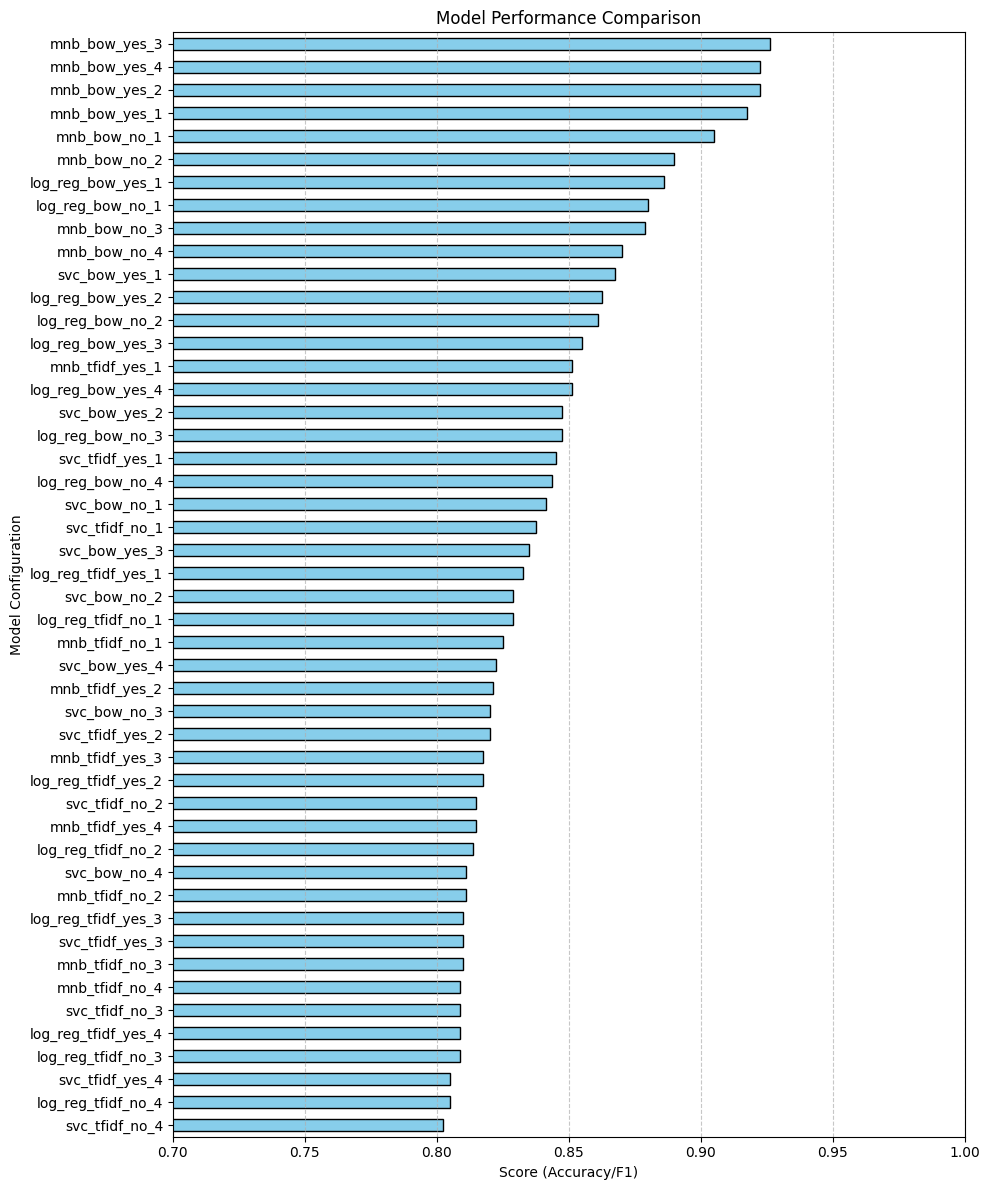

In [90]:
df = pd.DataFrame([(key, pipes[key]["accuracy"]) for key in pipes], columns=['Model', 'Score'])

df = df.sort_values(by='Score', ascending=True)

ax = df.plot(
    kind='barh', 
    x='Model', 
    y='Score', 
    figsize=(10, 12), 
    legend=False,
    color='skyblue',
    edgecolor='black'
)

plt.title('Model Performance Comparison')
plt.xlabel('Score (Accuracy/F1)')
plt.ylabel('Model Configuration')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(0.7, 1.0)

plt.tight_layout()
plt.show()